# Medical Cost Prediction — Exploratory Data Analysis
**File:** `analyze_src/eda.ipynb`  |  **Template:** Georginh0/house_price_prediction

**Dataset:** 1338 rows x 7 cols  |  **Target:** `charges` (USD)  |  **Task:** Regression

Run this notebook from the project root: `cd analyze_src && jupyter notebook eda.ipynb`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

df = pd.read_csv('../data/raw/insurance.csv')
print(f'Shape: {df.shape}')
df.head(10)


Shape: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


## 1 — Dataset Overview

In [2]:
print('=== Data Types ===');     print(df.dtypes)
print('\n=== Missing Values ==='); print(df.isnull().sum())
print(f'\nDuplicate rows: {df.duplicated().sum()}')
df.describe(include='all')


=== Data Types ===
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

=== Missing Values ===
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Duplicate rows: 1


,age,sex,bmi,children,smoker,region,charges
count,1338.000000,1338,1338.000000,1338.000000,1338,1338,1338.000000
unique,NaN,2,NaN,NaN,2,4,NaN
top,NaN,male,NaN,NaN,no,southeast,NaN
freq,NaN,676,NaN,NaN,1064,364,NaN
mean,39.207025,NaN,30.663397,1.094918,NaN,NaN,13270.422265
std,14.049960,NaN,6.098187,1.205493,NaN,NaN,12110.011237
min,18.000000,NaN,15.960000,0.000000,NaN,NaN,1121.873900
25%,27.000000,NaN,26.296250,0.000000,NaN,NaN,4740.287150
50%,39.000000,NaN,30.400000,1.000000,NaN,NaN,9382.033000
75%,51.000000,NaN,34.693750,2.000000,NaN,NaN,16639.912515


In [3]:
for col in ['sex', 'smoker', 'region']:
    print(f'\n--- {col} ---')
    vc  = df[col].value_counts()
    pct = df[col].value_counts(normalize=True).mul(100).round(1)
    print(pd.DataFrame({'count': vc, '%': pct}))



--- sex ---
        count     %
sex                
male      676  50.5
female    662  49.5

--- smoker ---
        count     %
smoker             
no       1064  79.5
yes       274  20.5

--- region ---
           count     %
region                
southeast    364  27.2
southwest    325  24.3
northwest    325  24.3
northeast    324  24.2


## 2 — Target Variable: charges

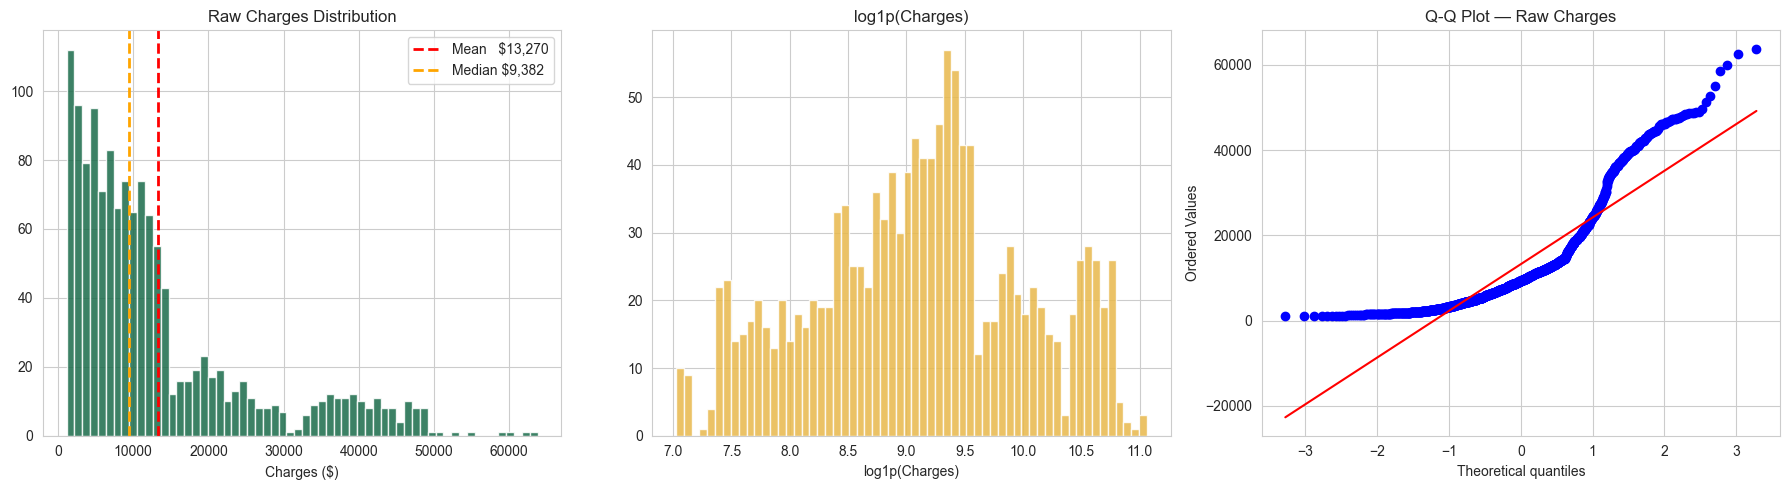

Skewness: 1.516
Kurtosis: 1.606
>> INSIGHT: Right-skewed (skew~1.51) => log1p transform needed for regression


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(df['charges'], bins=60, color='#1a6b4a', edgecolor='white', alpha=0.85)
m = df['charges'].mean(); med = df['charges'].median()
axes[0].axvline(m,   color='red',    ls='--', lw=2, label=f'Mean   ${m:,.0f}')
axes[0].axvline(med, color='orange', ls='--', lw=2, label=f'Median ${med:,.0f}')
axes[0].set_title('Raw Charges Distribution'); axes[0].set_xlabel('Charges ($)'); axes[0].legend()

axes[1].hist(np.log1p(df['charges']), bins=60, color='#e8b84b', edgecolor='white', alpha=0.85)
axes[1].set_title('log1p(Charges)'); axes[1].set_xlabel('log1p(Charges)')

stats.probplot(df['charges'], dist='norm', plot=axes[2])
axes[2].set_title('Q-Q Plot — Raw Charges')

plt.tight_layout()
plt.savefig('../reports/01_charges_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Skewness: {df["charges"].skew():.3f}')
print(f'Kurtosis: {df["charges"].kurt():.3f}')
print('>> INSIGHT: Right-skewed (skew~1.51) => log1p transform needed for regression')


## 3 — Categorical Features vs charges

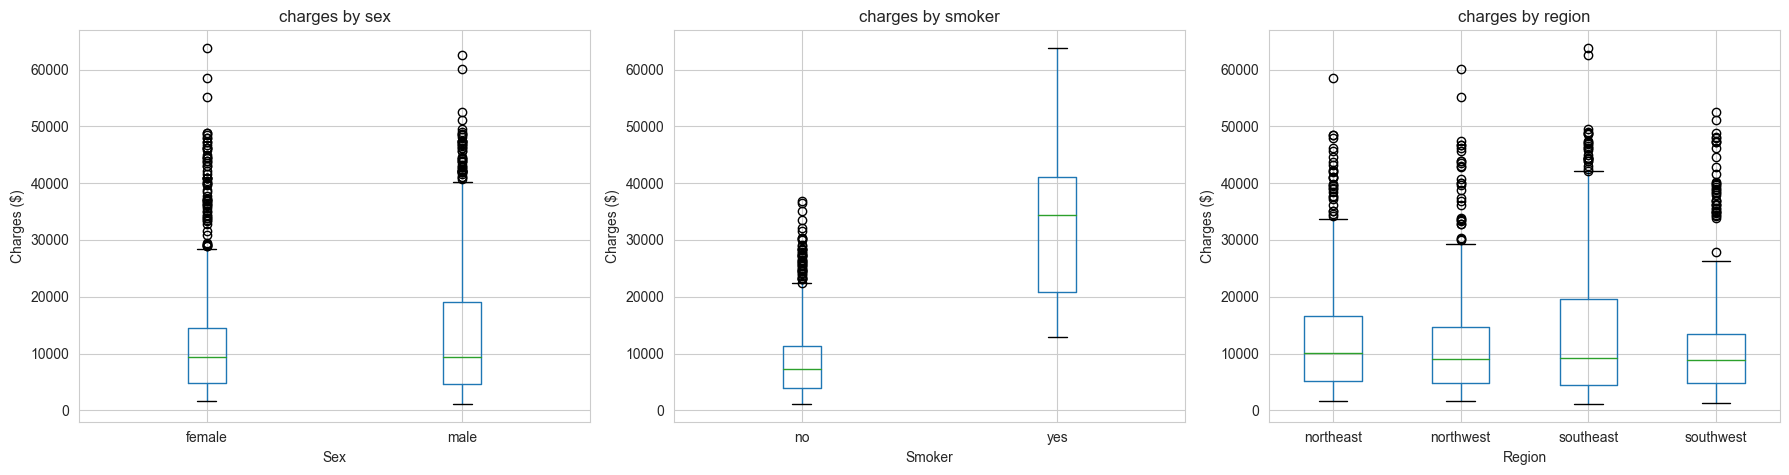

         count      mean       std       min       25%       50%       75%  \
smoker                                                                       
no      1064.0   8434.27   5993.78   1121.87   3986.44   7345.41  11362.89   
yes      274.0  32050.23  11541.55  12829.46  20826.24  34456.35  41019.21   

             max  
smoker            
no      36910.61  
yes     63770.43  

>> INSIGHT: Smokers pay 3.8x more on average — strongest predictor


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(['sex', 'smoker', 'region']):
    df.boxplot(column='charges', by=col, ax=axes[i])
    axes[i].set_title(f'charges by {col}')
    axes[i].set_xlabel(col.title())
    axes[i].set_ylabel('Charges ($)')
plt.suptitle('')
plt.tight_layout()
plt.savefig('../reports/02_categorical_vs_charges.png', dpi=150, bbox_inches='tight')
plt.show()

ratio = df[df.smoker=='yes']['charges'].mean() / df[df.smoker=='no']['charges'].mean()
print(df.groupby('smoker')['charges'].describe().round(2))
print(f'\n>> INSIGHT: Smokers pay {ratio:.1f}x more on average — strongest predictor')


## 4 — Numeric Features Analysis

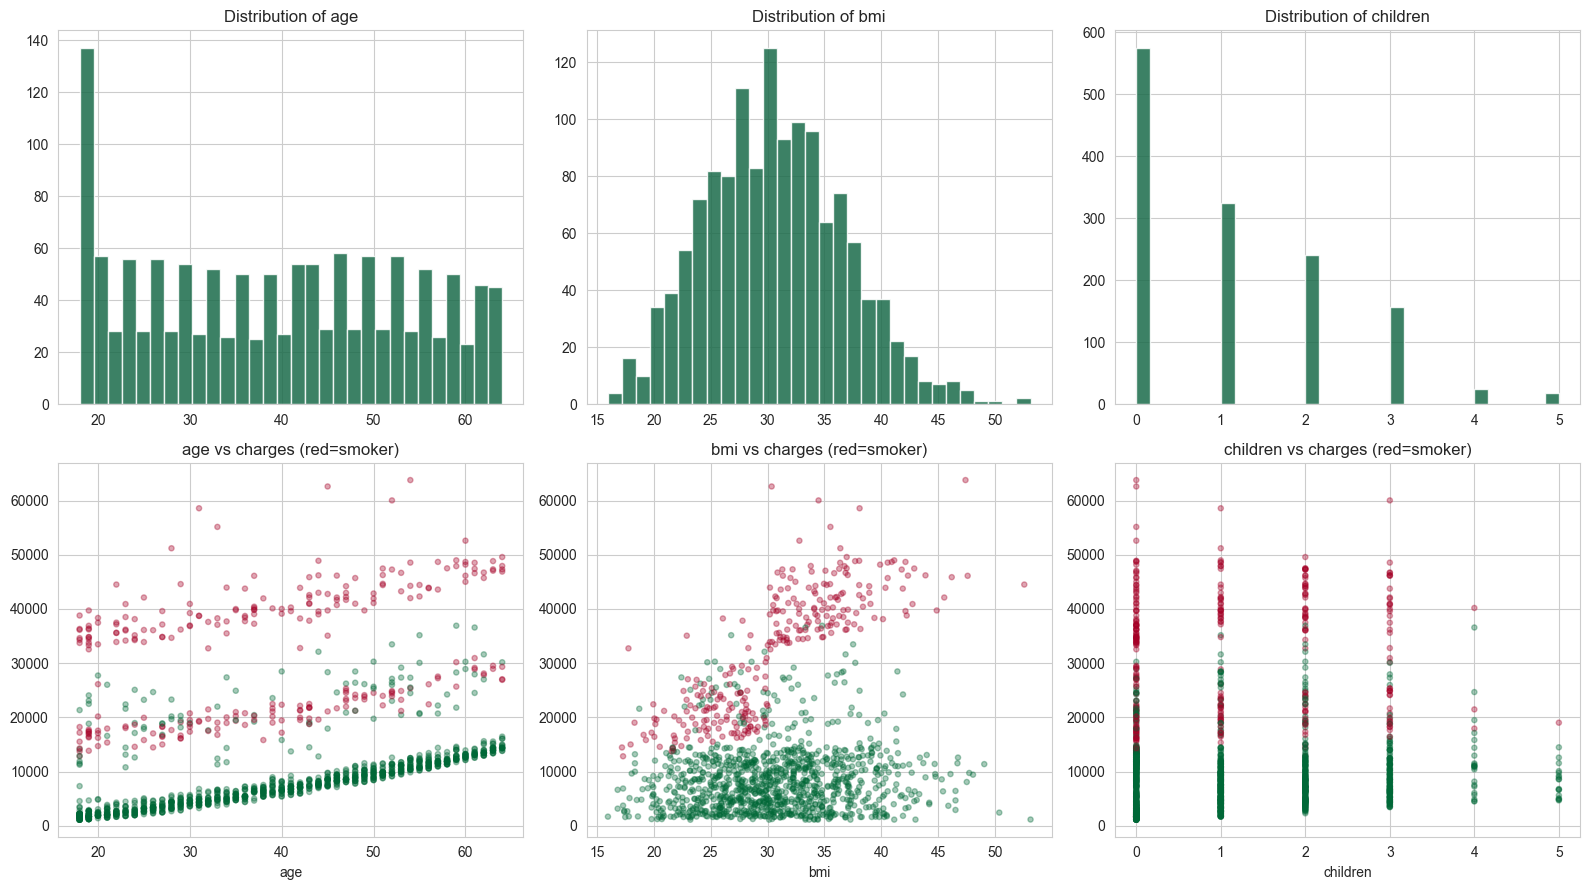

Pearson correlations with charges:
charges     1.000000
smoker_n    0.787251
age         0.299008
bmi         0.198341
children    0.067998
sex_n       0.057292
Name: charges, dtype: float64

>> INSIGHT: smoker(0.79) > age(0.30) > bmi(0.20) > children(0.07)


In [6]:
num_cols = ['age', 'bmi', 'children']
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for i, col in enumerate(num_cols):
    axes[0,i].hist(df[col], bins=30, color='#1a6b4a', alpha=0.85, edgecolor='white')
    axes[0,i].set_title(f'Distribution of {col}')
    sc = axes[1,i].scatter(
        df[col], df['charges'],
        c=df['smoker'].map({'yes':1,'no':0}),
        cmap='RdYlGn_r', alpha=0.35, s=14,
    )
    axes[1,i].set_title(f'{col} vs charges (red=smoker)')
    axes[1,i].set_xlabel(col)

plt.tight_layout()
plt.savefig('../reports/03_numeric_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

df_enc = df.copy()
df_enc['smoker_n'] = (df['smoker']=='yes').astype(int)
df_enc['sex_n']    = (df['sex']=='male').astype(int)
print('Pearson correlations with charges:')
print(df_enc[['age','bmi','children','smoker_n','sex_n','charges']].corr()['charges'].sort_values(ascending=False))
print('\n>> INSIGHT: smoker(0.79) > age(0.30) > bmi(0.20) > children(0.07)')


## 5 — Correlation Heatmap

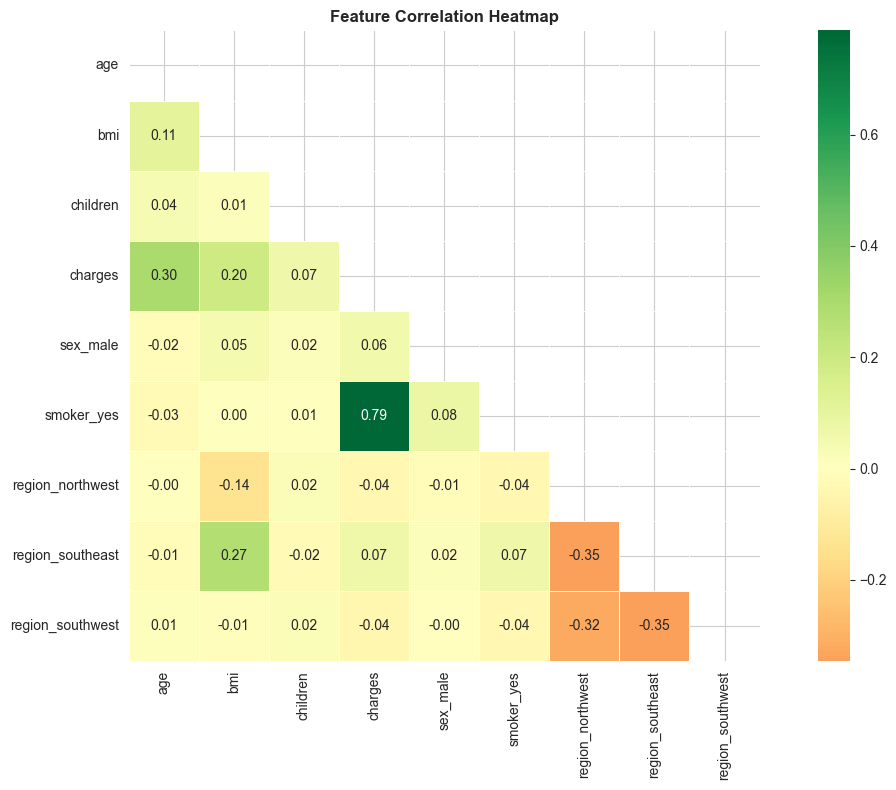

In [7]:
df_dum = pd.get_dummies(df, drop_first=True)
plt.figure(figsize=(12, 8))
mask = np.triu(np.ones_like(df_dum.corr(), dtype=bool))
sns.heatmap(df_dum.corr(), mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, square=True, linewidths=.5)
plt.title('Feature Correlation Heatmap', fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/04_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


## 6 — Smoker x BMI Interaction (Key EDA Finding)

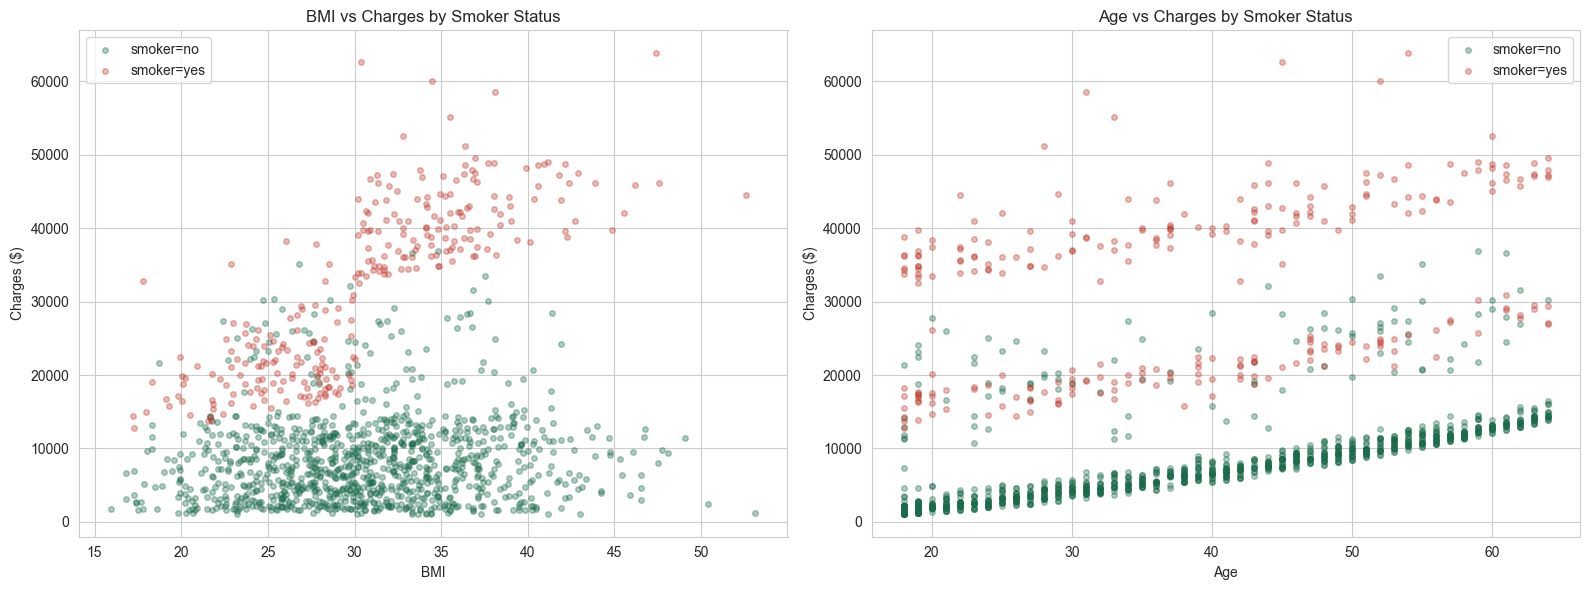

THREE DISTINCT CHARGE CLUSTERS IDENTIFIED:
  1. Non-smokers             -> low charges, linear with age
  2. Smokers + BMI < 30      -> medium-high charges
  3. Smokers + BMI >= 30     -> very high charges
  => smoker_bmi interaction is the most powerful engineered feature


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
clr = {'yes':'#c0392b', 'no':'#1a6b4a'}

for sv, grp in df.groupby('smoker'):
    axes[0].scatter(grp['bmi'],  grp['charges'], c=clr[sv], label=f'smoker={sv}', alpha=0.35, s=16)
    axes[1].scatter(grp['age'], grp['charges'],  c=clr[sv], label=f'smoker={sv}', alpha=0.35, s=16)

for ax, xl in zip(axes, ['BMI','Age']):
    ax.set_xlabel(xl); ax.set_ylabel('Charges ($)')
    ax.set_title(f'{xl} vs Charges by Smoker Status'); ax.legend()

plt.tight_layout()
plt.savefig('../reports/05_smoker_interaction.png', dpi=150, bbox_inches='tight')
plt.show()

print('THREE DISTINCT CHARGE CLUSTERS IDENTIFIED:')
print('  1. Non-smokers             -> low charges, linear with age')
print('  2. Smokers + BMI < 30      -> medium-high charges')
print('  3. Smokers + BMI >= 30     -> very high charges')
print('  => smoker_bmi interaction is the most powerful engineered feature')


## 7 — Outlier Analysis

In [9]:
print('=== IQR Outlier Detection ===')
for col in ['age', 'bmi', 'charges']:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    iqr = Q3 - Q1
    n = ((df[col] < Q1-1.5*iqr) | (df[col] > Q3+1.5*iqr)).sum()
    print(f'  {col:<10}: {n} outliers ({100*n/len(df):.1f}%)')

print('\nDecision: RETAIN all outliers.')
print('  High-cost rows are genuine medical cases (smoker+obese cohort).')
print('  log1p transform compresses extremes naturally at training time.')


=== IQR Outlier Detection ===
  age       : 0 outliers (0.0%)
  bmi       : 9 outliers (0.7%)
  charges   : 139 outliers (10.4%)

Decision: RETAIN all outliers.
  High-cost rows are genuine medical cases (smoker+obese cohort).
  log1p transform compresses extremes naturally at training time.


## 8 — EDA Summary and Feature Engineering Plan

In [10]:
print('='*58)
print('  EDA SUMMARY')
print('='*58)
print(f'  Dataset         : {len(df)} rows x {len(df.columns)} cols')
print(f'  Missing values  : {df.isnull().sum().sum()}')
print(f'  Duplicates      : {df.duplicated().sum()}')
print(f'  Target skewness : {df["charges"].skew():.3f} => log1p transform')
print(f'  #1 predictor    : smoker (r=0.79)')
print()
print('  FEATURE ENGINEERING  (steps/feature_engineering_step.py)')
print('  ' + '-'*52)
print('  smoker_bmi  = smoker x bmi        obese-smoker cluster')
print('  smoker_age  = smoker x age        older smokers cost more')
print('  bmi_obese   = 1 if bmi >= 30      obesity flag')
print('  high_risk   = smoker AND obese    combined risk')
print('  bmi_age     = bmi x age / 100     ageing amplifies BMI')
print('  age_group   = cut(age, 4 bins)    life-stage grouping')
print('  One-hot: sex, smoker, region, age_group')
print('  Target: log1p(charges) for training -> expm1 at inference')


  EDA SUMMARY
  Dataset         : 1338 rows x 7 cols
  Missing values  : 0
  Duplicates      : 1
  Target skewness : 1.516 => log1p transform
  #1 predictor    : smoker (r=0.79)

  FEATURE ENGINEERING  (steps/feature_engineering_step.py)
  ----------------------------------------------------
  smoker_bmi  = smoker x bmi        obese-smoker cluster
  smoker_age  = smoker x age        older smokers cost more
  bmi_obese   = 1 if bmi >= 30      obesity flag
  high_risk   = smoker AND obese    combined risk
  bmi_age     = bmi x age / 100     ageing amplifies BMI
  age_group   = cut(age, 4 bins)    life-stage grouping
  One-hot: sex, smoker, region, age_group
  Target: log1p(charges) for training -> expm1 at inference
